In [1]:
import jax, jax.numpy as jnp

from untangle.scaler import JacobianScaler
from untangle.algorithm import cmtf_bsd, cmtf_psd
from untangle.utils import collect_information, function_error

key  = jax.random.key(0)

In [2]:
N = 40
dofs = list(range(5, N, 2)) + [36, 38, 32, N]
print(dofs)

def f(x):
    x1, x2, x3 = x
    return jnp.array([
        x1**3 - 2*x1**2 + x1*x3,
        x2**3 + x3**2 - x2*x1
    ])

niters = 100
rank = 5

[5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 36, 38, 32, 40]


In [3]:
results = {'psd': {}, 'bsd': {}}

T = 10

for dof, k in zip(dofs, jax.random.split(key, len(dofs))):
    print(f'dof = {dof}')

    X, Y, J = collect_information(f, N, key=k)

    results['psd'][dof] = ([], [])
    results['bsd'][dof] = ([], [])
    
    for kk in jax.random.split(k, T):
        f_hat = cmtf_bsd(X, Y, J, rank, niters=niters, dof=dof, key=kk)
        errors = function_error(f, f_hat, X)
        results['bsd'][dof][0].append(errors[0])
        results['bsd'][dof][1].append(errors[1])

    for kk in jax.random.split(k, T):
        f_hat = cmtf_psd(X, Y, J, rank, niters=niters, dof=dof, key=kk)
        errors = function_error(f, f_hat, X)
        results['psd'][dof][0].append(errors[0])
        results['psd'][dof][1].append(errors[1])

dof = 5


|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:03<00:00, 26.42it/s, error=0.1141, best=0.0988 (11)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 154.83it/s, error=0.1289, best=0.1289 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 160.63it/s, error=0.1027, best=0.0998 (78)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 154.38it/s, error=0.0651, best=0.0651 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 152.10it/s, error=0.0983, best=0.0983 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 151.76it/s, error=0.1117, best=0.1046 (77)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 145.07it/s, error=0.1500, best=0.1240 (64)]
|CMTF-BSD| (rank=5): 100%|██████████████████████

dof = 7


|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:02<00:00, 42.92it/s, error=0.0092, best=0.0092 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 158.09it/s, error=0.0311, best=0.0311 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 154.96it/s, error=0.0554, best=0.0554 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 156.79it/s, error=0.0082, best=0.0082 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 125.66it/s, error=0.1016, best=0.1016 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 123.48it/s, error=0.1995, best=0.1275 (56)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 125.09it/s, error=0.0248, best=0.0248 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████

3 is degenerate
3 is degenerate


...

|CMTF-PSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:17<00:00,  5.84it/s, error=0.0491, best=0.0476 (82)]
|CMTF-PSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:17<00:00,  5.83it/s, error=0.0358, best=0.0281 (62)]
|CMTF-PSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:17<00:00,  5.87it/s, error=0.0477, best=0.0391 (67)]


dof = 32


|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:05<00:00, 18.57it/s, error=0.0182, best=0.0171 (82)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 127.85it/s, error=0.0475, best=0.0320 (75)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 131.23it/s, error=0.1973, best=0.0506 (69)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 121.62it/s, error=0.0502, best=0.0457 (98)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 118.99it/s, error=0.0410, best=0.0334 (93)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 129.94it/s, error=0.0248, best=0.0199 (71)]
|CMTF-BSD| (rank=5): 100%|██████████████████████████████████████████| 100/100 [00:00<00:00, 133.80it/s, error=0.0156, best=0.0156 (99)]
|CMTF-BSD| (rank=5): 100%|██████████████████████

dof = 40


|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:09<00:00, 10.35it/s, error=0.0469, best=0.0361 (98)]
|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:03<00:00, 28.48it/s, error=0.0464, best=0.0317 (90)]
|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:04<00:00, 23.88it/s, error=0.0331, best=0.0110 (89)]
|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:04<00:00, 23.71it/s, error=0.0627, best=0.0306 (81)]
|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:05<00:00, 19.39it/s, error=0.0094, best=0.0094 (99)]
|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:04<00:00, 22.73it/s, error=0.0570, best=0.0233 (52)]
|CMTF-BSD| (rank=5): 100%|███████████████████████████████████████████| 100/100 [00:03<00:00, 25.39it/s, error=0.0561, best=0.0379 (83)]
|CMTF-BSD| (rank=5): 100%|██████████████████████

In [8]:
results

{'psd': {5: ([Array(1.8271214, dtype=float32),
    Array(3.236473, dtype=float32),
    Array(1.9961491, dtype=float32),
    Array(0.4877766, dtype=float32),
    Array(8.726181, dtype=float32),
    Array(6.7641997, dtype=float32),
    Array(2.6460629, dtype=float32),
    Array(5.149431, dtype=float32),
    Array(1.6626053, dtype=float32),
    Array(2.958546, dtype=float32)],
   [Array(13.016443, dtype=float32),
    Array(6.6607995, dtype=float32),
    Array(0.9141225, dtype=float32),
    Array(0.46242815, dtype=float32),
    Array(8.549974, dtype=float32),
    Array(5.9752064, dtype=float32),
    Array(0.5178201, dtype=float32),
    Array(5.8886895, dtype=float32),
    Array(0.7826557, dtype=float32),
    Array(7.6004477, dtype=float32)]),
  7: ([Array(1.0876567, dtype=float32),
    Array(22.773127, dtype=float32),
    Array(13.443012, dtype=float32),
    Array(3.5388782, dtype=float32),
    Array(21.639938, dtype=float32),
    Array(5.855568, dtype=float32),
    Array(0.11315027, dtype

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme('paper')

In [10]:
import numpy as np

dofs = sorted(results['psd'].keys())

mean_psd_1 = []
mean_psd_2 = []
mean_bsd_1 = []
mean_bsd_2 = []

for dof, (a, b) in zip(dofs, results['bsd'].values()):
    mean_bsd_1.append(np.mean(a))
    mean_bsd_2.append(np.mean(b))

for dof, (a, b) in zip(dofs, results['psd'].values()):
    mean_psd_1.append(np.mean(a))
    mean_psd_2.append(np.mean(b))

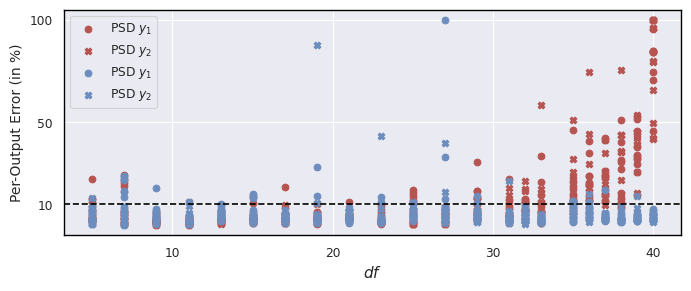

In [29]:
plt.figure(figsize=(7, 3))

points = results['bsd']

for dof in dofs:
    a, b = points[dof]
    for va in a: plt.scatter([dof], [min(va, 100)], color='#B85450')
    for vb in b: plt.scatter([dof], [min(vb, 100)], color='#B85450', marker='X')

plt.scatter([dof], [min(va, 100)], color='#B85450', label='PSD $y_1$')
plt.scatter([dof], [min(vb, 100)], color='#B85450', marker='X', label='PSD $y_2$')

points = results['psd']
for dof in dofs:
    a, b = points[dof]
    for va in a: plt.scatter([dof], [min(va, 100)], color='#6C8EBF')
    for vb in b: plt.scatter([dof], [min(vb, 100)], color='#6C8EBF', marker='X')
        
plt.scatter([dof], [min(va, 100)], color='#6C8EBF', label='PSD $y_1$')
plt.scatter([dof], [min(vb, 100)], color='#6C8EBF', marker='X', label='PSD $y_2$')

#plt.plot(dofs, mean_psd_1, color='#6C8EBF', label='PSD $y_1$')
#plt.plot(dofs, mean_psd_2, color='#6C8EBF', label='PSD $y_2$', linestyle='--')

#plt.plot(dofs, mean_bsd_1, color='#B85450', label='BSD $y_1$')
#plt.plot(dofs, mean_bsd_2, color='#B85450', label='BSD $y_1$', linestyle='--')

plt.axhline(10, color='black', linestyle='--')

# Add border around plot area
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

plt.xlabel('$df$', fontsize=11)
plt.ylabel('Per-Output Error (in %)', fontsize=10)
plt.yticks([10, 50, 100])
plt.xticks([10, 20, 30, 40])
plt.legend()
plt.tight_layout()
plt.savefig('bsd-psd-errors.png', dpi=200)
plt.show()